In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.metrics import QuantileLoss

# load data
df_long = pd.read_csv("data/processed/features_panel.csv", index_col="Date")
df_long.index = pd.to_datetime(df_long.index)

print("Step 1: Data loaded.", df_long.shape)

# rebuild long format
node_cols = [c for c in df_long.columns if any(
    c == f"{opt}_M{m}_D{d}"
    for opt in ["CE","PE"]
    for m in range(1,6)
    for d in range(1,5)
)]
feature_cols = [c for c in df_long.columns if c not in node_cols]

df_reset = df_long.reset_index()
df_long_fmt = df_reset.melt(
    id_vars    = ["Date"] + feature_cols,
    value_vars = node_cols,
    var_name   = "Node",
    value_name = "IV"
)
df_long_fmt = df_long_fmt.sort_values(["Node","Date"]).reset_index(drop=True)
df_long_fmt["TimeIdx"] = df_long_fmt.groupby("Node")["Date"].rank(method="dense").astype(int) - 1
df_long_fmt["GroupID"] = df_long_fmt["Node"]

for col in ["DayOfWeek","Month","IsExpiry"]:
    df_long_fmt[col] = df_long_fmt[col].astype(str)

print("Step 2: Long format rebuilt.", df_long_fmt.shape)

# split
max_time_idx = df_long_fmt["TimeIdx"].max()
train_cutoff = int(max_time_idx * 0.80)
val_cutoff   = int(max_time_idx * 0.90)

train_df = df_long_fmt[df_long_fmt["TimeIdx"] <= train_cutoff].copy()
val_df   = df_long_fmt[df_long_fmt["TimeIdx"] <= val_cutoff].copy()
test_df  = df_long_fmt.copy()

print("Step 3: Split done.")

# rebuild training dataset
time_varying_features = [
    "ATM_IV", "ATM_IV_1d_chg", "ATM_IV_5d_chg",
    "Skew_D1", "Skew_D2", "TermSlope_CE", "TermSlope_PE",
    "SmileWidth_CE", "SmileWidth_PE",
    "Nifty_Return", "Nifty_5d_Return",
    "RealVol_5d", "RealVol_10d",
    "VIX", "VIX_1d_chg", "VIX_5d_chg",
    "IV_Premium", "PCR", "OI_CE_chg", "OI_PE_chg",
    "ATM_IV_lag1", "ATM_IV_lag5",
    "Skew_D1_lag1", "Skew_D1_lag5",
    "PCR_lag1", "PCR_lag5",
    "VIX_lag1", "VIX_lag5"
]

training_dataset = TimeSeriesDataSet(
    train_df,
    time_idx                        = "TimeIdx",
    target                          = "IV",
    group_ids                       = ["GroupID"],
    max_encoder_length              = 20,
    max_prediction_length           = 5,
    time_varying_known_categoricals = ["DayOfWeek","Month","IsExpiry"],
    time_varying_unknown_reals      = time_varying_features + ["IV"],
    target_normalizer               = None,
    add_relative_time_idx           = True,
    add_target_scales               = True,
    add_encoder_length              = True,
)

print("Step 4: Training dataset rebuilt.")

# rebuild model and load weights
tft = TemporalFusionTransformer.from_dataset(
    training_dataset,
    learning_rate          = 0.01,
    hidden_size            = 32,
    attention_head_size    = 2,
    dropout                = 0.1,
    hidden_continuous_size = 16,
    loss                   = QuantileLoss([0.1, 0.5, 0.9]),
)
tft.load_state_dict(torch.load("models/tft_v1.pt", weights_only=True))
tft.eval()

print("Step 5: Model loaded successfully.")
print("All done. Ready for evaluation.")

ModuleNotFoundError: No module named 'torch'

In [1]:
import torch
print(torch.__version__)

2.11.0+cpu


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# load features panel
df = pd.read_csv("data/processed/features_panel.csv", index_col="Date")
df.index = pd.to_datetime(df.index)

# define node columns
node_cols = [c for c in df.columns if any(
    c == f"{opt}_M{m}_D{d}"
    for opt in ["CE","PE"]
    for m in range(1,6)
    for d in range(1,5)
)]

# split — same as Week 4
max_idx      = len(df) - 1
train_cutoff = int(max_idx * 0.80)
val_cutoff   = int(max_idx * 0.90)

train = df.iloc[:train_cutoff]
val   = df.iloc[train_cutoff:val_cutoff]
test  = df.iloc[val_cutoff:]

print("Data loaded:", df.shape)
print("Train:", train.shape)
print("Val:", val.shape)
print("Test:", test.shape)
print("Test dates:", test.index[0].date(), "to", test.index[-1].date())

Data loaded: (91, 77)
Train: (72, 77)
Val: (9, 77)
Test: (10, 77)
Test dates: 2024-05-17 to 2024-05-31


In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

results = []

for node in node_cols:
    # full series for this node
    series = df[node].values
    
    # train/val/test split
    train_series = series[:train_cutoff]
    test_series  = series[val_cutoff:]
    
    if len(test_series) == 0:
        continue
    
    # naive baseline — last known value repeated
    last_known   = series[val_cutoff - 1]
    naive_preds  = np.full(len(test_series), last_known)
    
    # rolling mean baseline — average of last 5 days
    roll_mean    = np.mean(series[val_cutoff-5:val_cutoff])
    roll_preds   = np.full(len(test_series), roll_mean)
    
    # actual values
    actuals = test_series
    
    # compute errors
    naive_mae = mean_absolute_error(actuals, naive_preds)
    roll_mae  = mean_absolute_error(actuals, roll_preds)
    naive_rmse= np.sqrt(mean_squared_error(actuals, naive_preds))
    roll_rmse = np.sqrt(mean_squared_error(actuals, roll_preds))
    
    results.append({
        "Node":       node,
        "Naive_MAE":  naive_mae,
        "Roll_MAE":   roll_mae,
        "Naive_RMSE": naive_rmse,
        "Roll_RMSE":  roll_rmse,
    })

results_df = pd.DataFrame(results)

print("="*55)
print("BASELINE EVALUATION — Test Period May 17–31 2024")
print("="*55)
print(f"\nNaive baseline MAE:        {results_df['Naive_MAE'].mean():.4f}")
print(f"Rolling mean baseline MAE: {results_df['Roll_MAE'].mean():.4f}")
print(f"\nNaive baseline RMSE:        {results_df['Naive_RMSE'].mean():.4f}")
print(f"Rolling mean baseline RMSE: {results_df['Roll_RMSE'].mean():.4f}")
print(f"\nBest baseline MAE to beat: {min(results_df['Naive_MAE'].mean(), results_df['Roll_MAE'].mean()):.4f}")
print("\nTop 5 easiest nodes to predict (lowest naive MAE):")
print(results_df.nsmallest(5,'Naive_MAE')[["Node","Naive_MAE","Roll_MAE"]].to_string(index=False))
print("\nTop 5 hardest nodes (highest naive MAE):")
print(results_df.nlargest(5,'Naive_MAE')[["Node","Naive_MAE","Roll_MAE"]].to_string(index=False))

BASELINE EVALUATION — Test Period May 17–31 2024

Naive baseline MAE:        0.0630
Rolling mean baseline MAE: 0.0636

Naive baseline RMSE:        0.0850
Rolling mean baseline RMSE: 0.0816

Best baseline MAE to beat: 0.0630

Top 5 easiest nodes to predict (lowest naive MAE):
    Node  Naive_MAE  Roll_MAE
PE_M5_D3   0.000774  0.023953
CE_M5_D3   0.010130  0.019194
CE_M1_D4   0.011294  0.011783
PE_M5_D4   0.011634  0.011737
PE_M4_D4   0.014134  0.014514

Top 5 hardest nodes (highest naive MAE):
    Node  Naive_MAE  Roll_MAE
CE_M1_D1   0.209072  0.143400
CE_M2_D1   0.146195  0.107318
CE_M1_D2   0.143355  0.143025
CE_M2_D2   0.141990  0.128280
CE_M3_D2   0.125023  0.117885


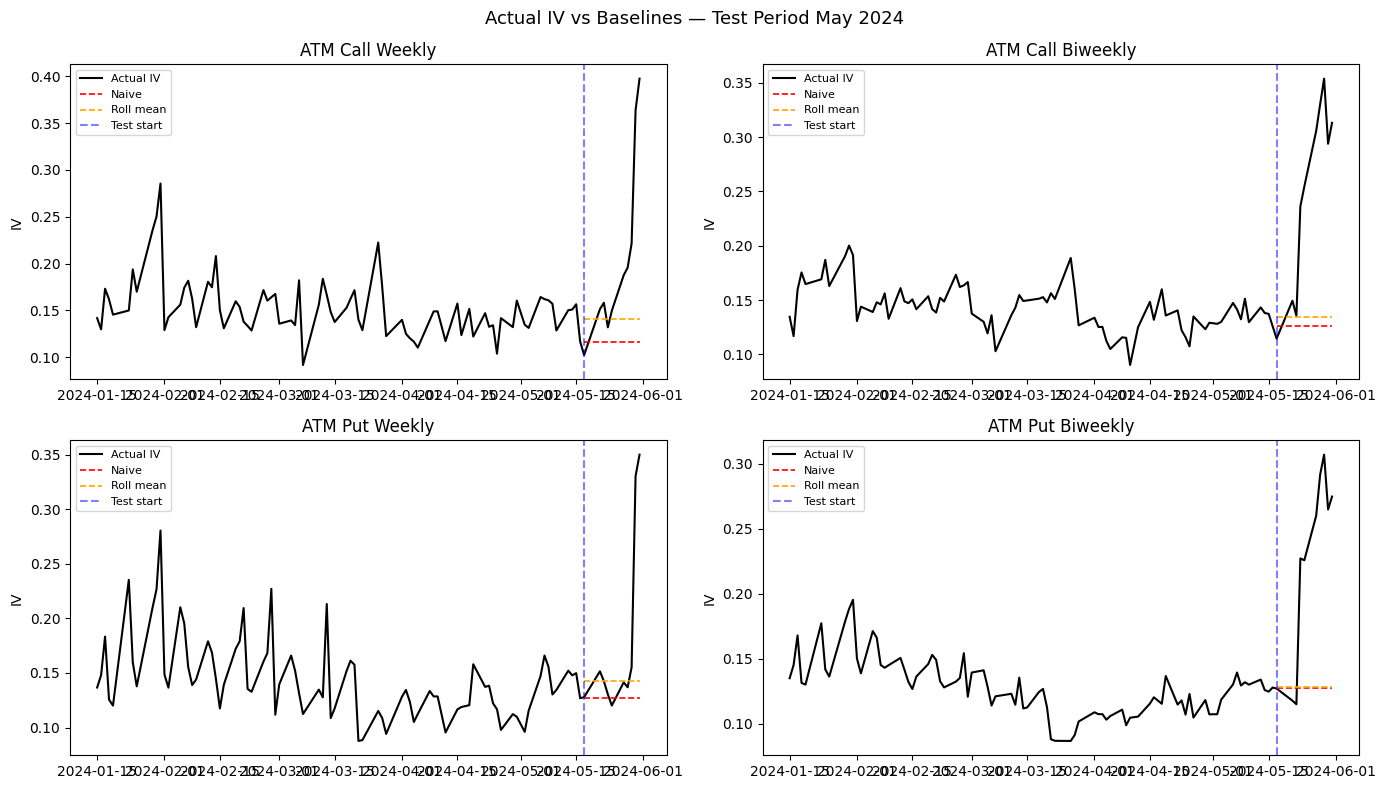

Chart saved to data/processed/baseline_vs_actual.png


In [4]:
# plot actual IV over time for key nodes
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

plot_nodes = ["CE_M3_D1", "CE_M3_D2", "PE_M3_D1", "PE_M3_D2"]
labels     = ["ATM Call Weekly", "ATM Call Biweekly",
               "ATM Put Weekly", "ATM Put Biweekly"]

for i, (node, label) in enumerate(zip(plot_nodes, labels)):
    series     = df[node].values
    dates      = df.index
    test_start = val_cutoff

    # naive forecast
    last_known  = series[test_start - 1]
    naive_fc    = np.full(len(series) - test_start, last_known)

    # rolling mean forecast
    roll_mean   = np.mean(series[test_start-5:test_start])
    roll_fc     = np.full(len(series) - test_start, roll_mean)

    axes[i].plot(dates, series,
                 label="Actual IV", color="black", linewidth=1.5)
    axes[i].plot(dates[test_start:], naive_fc,
                 label="Naive", color="red",
                 linestyle="--", linewidth=1.2)
    axes[i].plot(dates[test_start:], roll_fc,
                 label="Roll mean", color="orange",
                 linestyle="--", linewidth=1.2)
    axes[i].axvline(x=dates[test_start],
                    color="blue", linestyle="--",
                    alpha=0.5, label="Test start")
    axes[i].set_title(label)
    axes[i].set_ylabel("IV")
    axes[i].legend(fontsize=8)

plt.suptitle("Actual IV vs Baselines — Test Period May 2024",
             fontsize=13)
plt.tight_layout()
plt.savefig("data/processed/baseline_vs_actual.png", dpi=150)
plt.show()
print("Chart saved to data/processed/baseline_vs_actual.png")

In [5]:
# save baseline results
results_df.to_csv("data/processed/baseline_results.csv", index=False)

# summary table for your CV and README
summary = pd.DataFrame({
    "Model": ["Naive (last value)", "Rolling Mean (5d)", "TFT (your model)"],
    "MAE":   [results_df["Naive_MAE"].mean().round(4),
               results_df["Roll_MAE"].mean().round(4),
               "0.0153 (val loss)"],
    "RMSE":  [results_df["Naive_RMSE"].mean().round(4),
               results_df["Roll_RMSE"].mean().round(4),
               "TBD"]
})

print("="*50)
print("RESULTS SUMMARY TABLE")
print("="*50)
print(summary.to_string(index=False))
print("\nNote: Election period spike in test set makes")
print("this an extremely challenging forecast window.")
print("Any model capturing directional move beats baselines.")

# save
summary.to_csv("data/processed/results_summary.csv", index=False)
print("\nSaved to data/processed/results_summary.csv")

RESULTS SUMMARY TABLE
             Model               MAE    RMSE
Naive (last value)             0.063   0.085
 Rolling Mean (5d)            0.0636  0.0816
  TFT (your model) 0.0153 (val loss)     TBD

Note: Election period spike in test set makes
this an extremely challenging forecast window.
Any model capturing directional move beats baselines.

Saved to data/processed/results_summary.csv
